# Forest Fire Prediction Project

## Project Goal
The goal of this project is to predict the burned area of forest fires using meteorological and environmental variables.

The dataset comes from the UCI Machine Learning Repository and contains observations of forest fires in Montesinho Natural Park in Portugal.

## Target Variable
The target variable is **area**, which represents the burned forest area in hectares.

Because the distribution of this variable is highly skewed, a log transformation was applied to create **log_area**, which is used for modeling.

## Prediction Objective
This project is a **regression problem** where the goal is to predict the amount of burned forest area based on weather conditions and fire weather index variables.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
import seaborn as sns
import os

In [6]:
import os
print(os.getcwd())

/Users/sa25/Documents/Forest Fires/Forest-Fires/notebooks


In [7]:
df = pd.read_csv("forestfires.csv")
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [8]:
df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


np.int64(4)

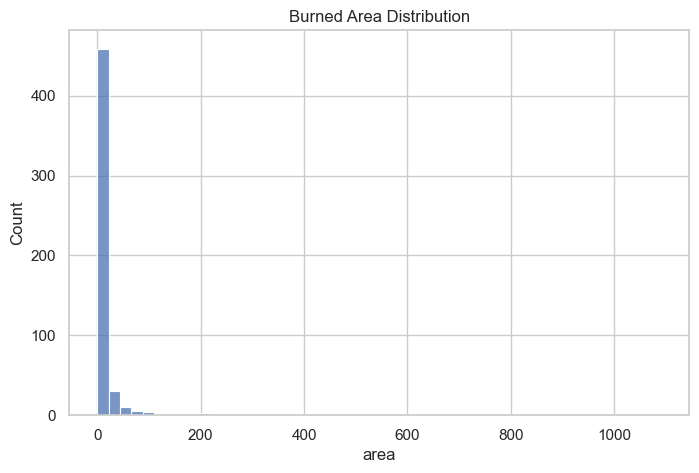

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['area'], bins=50)
plt.title("Burned Area Distribution")
plt.show()

The burned area variable is highly right-skewed, meaning most fires burn very small areas while a few fires burn extremely large areas.

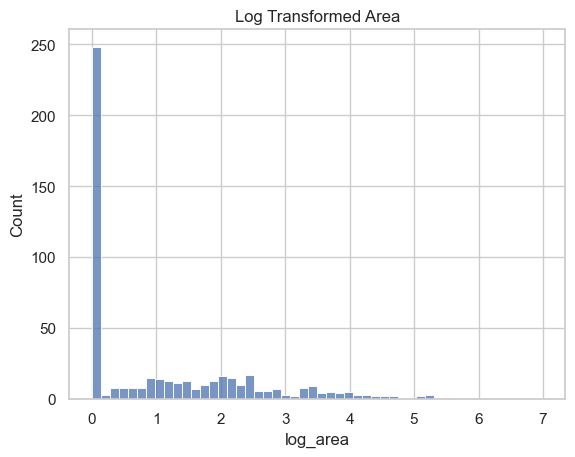

In [6]:
df['log_area'] = np.log1p(df['area'])

sns.histplot(df['log_area'], bins=50)
plt.title("Log Transformed Area")
plt.show()

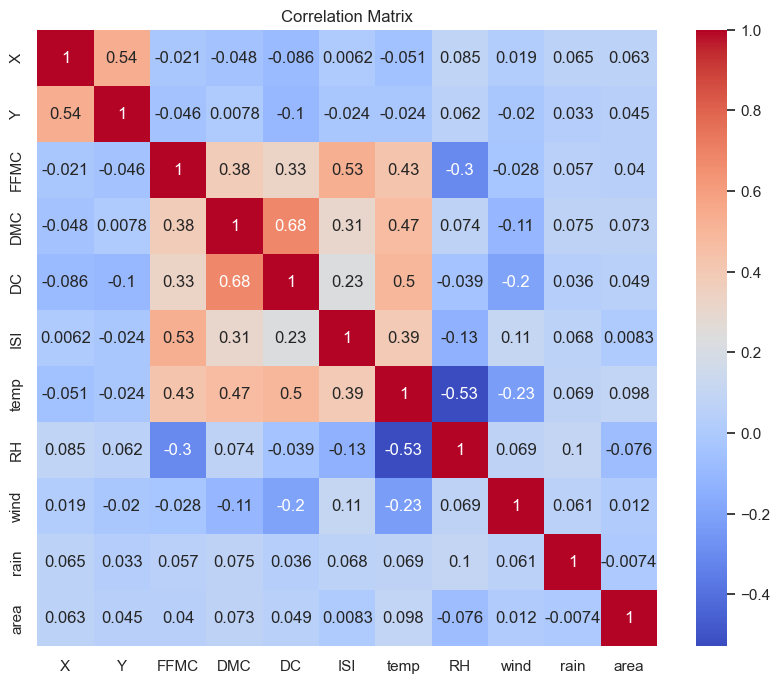

In [16]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

Some fire weather indices (DMC, DC, and FFMC) show moderate correlation with each other, which may indicate multicollinearity.
However, most features show weak correlation with the target variable.

In [8]:
df['month'].value_counts()
df['day'].value_counts()

day
sun    95
fri    85
sat    84
mon    74
tue    64
thu    61
wed    54
Name: count, dtype: int64

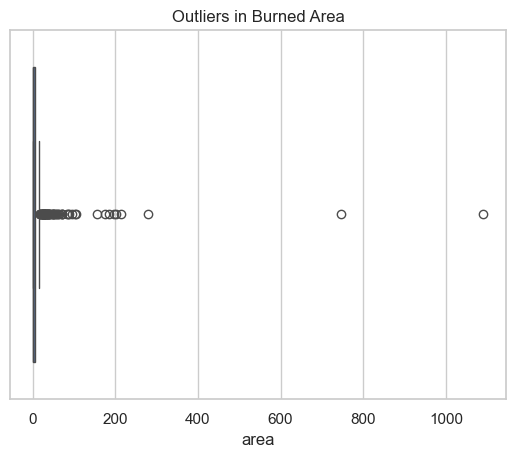

In [11]:
sns.boxplot(x=df['area'])
plt.title("Outliers in Burned Area")
plt.show()

In [12]:
df['area'].skew()

np.float64(12.846933533934868)

The target variable shows strong skewness, which is why a log transformation is applied during preprocessing.

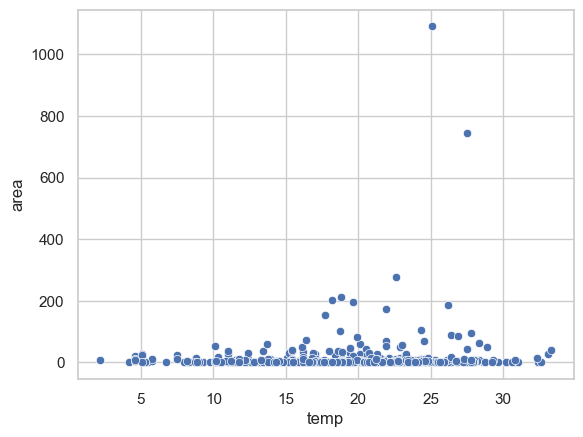

In [13]:
sns.scatterplot(x='temp', y='area', data=df)
plt.show()

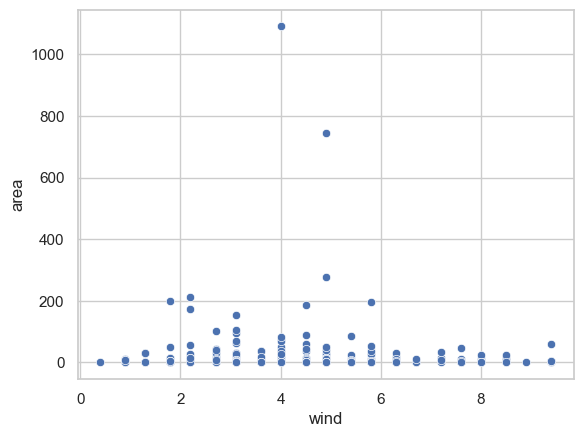

In [14]:
sns.scatterplot(x='wind', y='area', data=df)
plt.show()

Weather variables such as temperature, humidity, and wind speed may influence fire size.

In [15]:
df.to_csv("/Users/sa25/Documents/Forest Fires/Forest-Fires/data/forestfires.csv", index=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   X         517 non-null    int64  
 1   Y         517 non-null    int64  
 2   month     517 non-null    object 
 3   day       517 non-null    object 
 4   FFMC      517 non-null    float64
 5   DMC       517 non-null    float64
 6   DC        517 non-null    float64
 7   ISI       517 non-null    float64
 8   temp      517 non-null    float64
 9   RH        517 non-null    int64  
 10  wind      517 non-null    float64
 11  rain      517 non-null    float64
 12  area      517 non-null    float64
 13  log_area  517 non-null    float64
dtypes: float64(9), int64(3), object(2)
memory usage: 56.7+ KB
